# Feature Selection

Taking the top models from the different notebooks we will see the features that have been selected by these different models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import pandas as pd

In [2]:
def return_scores(estimator, X_train, X_test, y_train, y_test):
    estimator = estimator
    train_score = estimator.score(X_train, y_train)
    test_score = estimator.score(X_test, y_test)

    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)

    train_recall = recall_score(y_train, estimator.predict(X_train))
    test_recall = recall_score(y_test, estimator.predict(X_test))

    train_prec = precision_score(y_train, train_pred)
    test_prec = precision_score(y_test, test_pred)

    df = pd.DataFrame({
        'Accuracy': [train_score, test_score],
        'Recall': [train_recall, test_recall],
        'Precision': [train_prec, test_prec]
    }, index=['Train', 'Test'])

    return df

def return_df(path=str()):
    df = pd.read_csv(path)
    cols = df['Unnamed: 0'].values
    df.drop('Unnamed: 0', axis=1, inplace=True)
    df.index = cols

    return df

In [3]:
log_coef_df = return_df('log_reg_coefs.csv')
log_coef_df

,Coefficients
I paid good price for my order,-0.245953
contents of my order was as I expected,0.000000
I ordered everything I wanted to order,0.000000
the app makes ordering easy,0.000000
my order was delivered on time,0.051681
I am satisfied with my courier,0.267268


In [4]:
svc_coef = return_df('svc_coefs.csv')
svc_coef

,Coefficients
I paid good price for my order,-0.093966
contents of my order was as I expected,-0.000012
I ordered everything I wanted to order,0.000050
the app makes ordering easy,0.022054
I am satisfied with my courier,0.187871
my order was delivered on time,0.895308


In [5]:
bagging_features = return_df('bagging_features.csv')
bagging_features

,Importance
I paid good price for my order,0.099435
contents of my order was as I expected,0.101874
the app makes ordering easy,0.129079
I ordered everything I wanted to order,0.171645
I am satisfied with my courier,0.200661
my order was delivered on time,0.297306


In [6]:
sgd_features = return_df('sgd_features.csv')
sgd_features

,Importance
I paid good price for my order,0.076831
I am satisfied with my courier,0.134616
contents of my order was as I expected,0.138089
the app makes ordering easy,0.183840
I ordered everything I wanted to order,0.206389
my order was delivered on time,0.260234


In [7]:
total_df = pd.concat([log_coef_df, svc_coef, bagging_features, sgd_features],
                     axis=1)
total_df.columns=['Logistic Regression Coefficients',
                     'SVC Linear Coefficients',
                     'Bagging Features',
                     'SGD Features']

total_df

,Logistic Regression Coefficients,SVC Linear Coefficients,Bagging Features,SGD Features
I paid good price for my order,-0.245953,-0.093966,0.099435,0.076831
contents of my order was as I expected,0.000000,-0.000012,0.101874,0.138089
I ordered everything I wanted to order,0.000000,0.000050,0.171645,0.206389
the app makes ordering easy,0.000000,0.022054,0.129079,0.183840
my order was delivered on time,0.051681,0.895308,0.297306,0.260234
I am satisfied with my courier,0.267268,0.187871,0.200661,0.134616


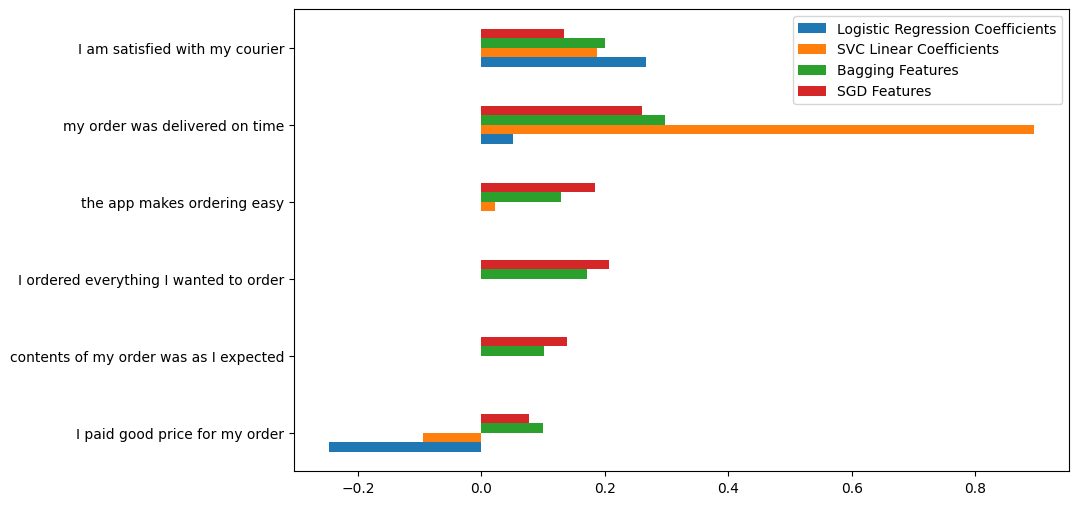

In [8]:
total_df.plot(kind='barh', figsize=(10,6))
plt.legend()
plt.show()

In [9]:
import pickle

with open('../Notebooks/models/data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test, sgd_model = pickle.load(f)

In [10]:
sgd_model.fit(X_train, y_train)

return_scores(sgd_model, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.960000,0.981818,0.947368
Test,0.846154,0.857143,0.857143


## Dataset Testing

Using the whole dataset, we will check that the model performs as we expect.

In [14]:
X = pd.concat([X_train, X_test], axis=0)

X

,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
23,5,1,2,5,2,4
25,3,4,3,3,2,3
85,5,2,3,4,4,5
90,3,4,5,4,5,4
92,5,4,5,5,5,4
...,...,...,...,...,...,...
73,5,2,3,3,2,5
103,4,3,4,4,3,4
9,4,4,4,2,5,5
54,4,3,2,4,3,4


In [15]:
y = pd.concat([pd.Series(y_train), pd.Series(y_test)], axis=0)
y

0     1
1     0
2     1
3     0
4     1
     ..
21    0
22    1
23    0
24    1
25    0
Length: 126, dtype: int64

In [19]:
sgd_model.fit(X, y)

preds =  sgd_model.predict(X)

print(f"Model accuracy score: {sgd_model.score(X, y)}")
print(f"Model recall score: {recall_score(y, preds)}")
print(f"Model precision score: {precision_score(y, preds)}")

Model accuracy score: 0.9444444444444444
Model recall score: 0.9420289855072463
Model precision score: 0.9558823529411765
